[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/seap-udea/MultiNEAs/blob/main/examples/probability_tutorial.ipynb)

# MultiNEAs: Pympact completeness

## Installation

If you're running this in Google Colab or need to install the package, uncomment and run the following cell:

In [66]:
try:
    from google.colab import drive
    %pip install -Uq multineas
except ImportError:
    print("Not running in Colab, skipping installation")
    %load_ext autoreload
    %autoreload 2
!mkdir -p gallery
# Uncomment to install from GitHub (development version)
# !pip install git+https://github.com/seap-udea/MultiNEAs.git

Not running in Colab, skipping installation
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load the Package

Import `multineas.probability` and other required libraries:

In [67]:
import multineas as neas

## Testing pympact

In [68]:
import multineas.pympact as pm

In [69]:
pm.asteroid_classes

{'IEO': {'name': 'Atira',
  'type': 'asteroid',
  'description': 'An asteroid orbit contained entirely within the orbit of the Earth (Q < 0.983 au). Also known as an Interior Earth Object'},
 'ATE': {'name': 'Aten',
  'type': 'asteroid',
  'description': 'Near-Earth asteroid orbits similar to that of 2062 Aten (a < 1.0 au; Q > 0.983 au)'},
 'APO': {'name': 'Apollo',
  'type': 'asteroid',
  'description': 'Near-Earth asteroid orbits which cross the Earth’s orbit similar to that of 1862 Apollo (a > 1.0 au; q < 1.017 au)'},
 'AMO': {'name': 'Amor',
  'type': 'asteroid',
  'description': 'Near-Earth asteroid orbits similar to that of 1221 Amor (1.017 au < q < 1.3 au)'},
 'MCA': {'name': 'Mars-crossing Asteroid',
  'type': 'asteroid',
  'description': 'Asteroids that cross the orbit of Mars constrained by (1.3 au < q < 1.666 au; a < 3.2 au)'},
 'IMB': {'name': 'Inner Main-belt Asteroid',
  'type': 'asteroid',
  'description': 'Asteroids with orbital elements constrained by (a < 2.0 au; q > 

In [70]:
from multineas import constants as const

In [71]:
const.mu_sun


1.3271244004127942e+20

### Asteroid population

In [72]:
import numpy as np
import multimin as mm
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
neo_db = pm.read_neo_db(pm.data_dir, type='df')
nea_db = neo_db[neo_db['kind'].isin(['an', 'au'])]
nea_db = nea_db.dropna(subset=['H'])
print(f"Number of NEAs (with known H): {len(nea_db)}")


Loaded neo_db with 41122 objects from data/neo_db.csv.gz
Number of NEAs (with known H): 40911


In [74]:
# NEAs well-known
nea_wkn = nea_db.dropna(subset=['albedo','diameter'])

# Drop neas with extent instead of diameter
nea_wkn = nea_wkn[nea_wkn['extent'].isna()]
print(f"Number of well-known NEAs: {len(nea_wkn)}")

Number of well-known NEAs: 1194


Fitting H-d relationship function parameters:

In [75]:
C_std = 1329.22
a_std = 0.2

# Define the model function
def diameter_model(H, C, a, p):
    return C * 10**(-a * H) / p**0.5

# Extract the necessary data
H = nea_wkn['H'].values
p = nea_wkn['albedo'].values
diameter = nea_wkn['diameter'].values

# Initial guess for the parameters
initial_guess = [1329.22, 0.2]

# Perform the curve fitting
params, covariance = curve_fit(lambda H, C, a: diameter_model(H, C, a, p), H, diameter, p0=initial_guess)

# Extract the best-fit parameters
C_best, a_best = params

print(f"Standard parameters: C = {C_std}, a = {a_std}")
print(f"Best-fit parameters: C = {C_best}, a = {a_best}")

Standard parameters: C = 1329.22, a = 0.2
Best-fit parameters: C = 1209.044729988792, a = 0.19806816990606088


In [76]:
nea_wkn = nea_wkn.assign(diameter_std = C_std*10**(-a_std*nea_wkn['H'])/np.sqrt(nea_wkn['albedo']))
nea_wkn = nea_wkn.assign(diameter_best = C_best*10**(-a_best*nea_wkn['H'])/np.sqrt(nea_wkn['albedo']))
nea_wkn = nea_wkn.assign(error_diameter_best = np.log10(abs(nea_wkn['diameter'] - nea_wkn['diameter_best'])/nea_wkn['diameter']))
nea_wkn = nea_wkn.assign(error_diameter_std = np.log10(abs(nea_wkn['diameter'] - nea_wkn['diameter_std'])/nea_wkn['diameter']))

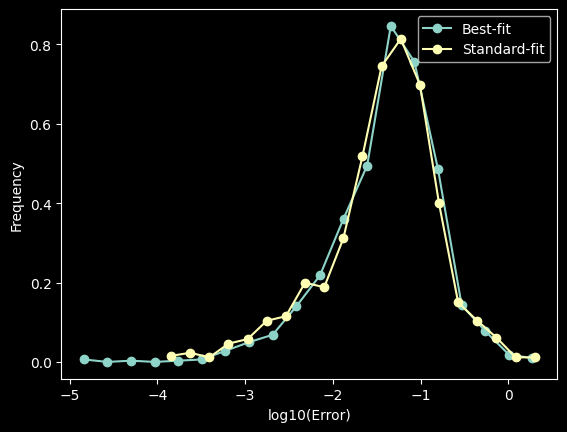

In [77]:
bins = 20

h_best,x_best = np.histogram(nea_wkn.error_diameter_best, bins=bins, density=True)
x_best = (x_best[1:] + x_best[:-1])/2

h_std,x_std = np.histogram(nea_wkn.error_diameter_std, bins=bins, density=True)
x_std = (x_std[1:] + x_std[:-1])/2

plt.plot(x_best,h_best,'o-',label='Best-fit')
plt.plot(x_std,h_std,'o-',label='Standard-fit')

plt.xlabel('log10(Error)')
plt.ylabel('Frequency')

plt.legend()


Estimate diameter for asteroid whose albedo is known

In [78]:
cond = (~nea_db.albedo.isna()) & (nea_db.diameter.isna())
print(f"Number of NEAs with known albedo and unknown diameter: {cond.sum()}")
nea_db.loc[cond, 'diameter'] = diameter_model(nea_db.loc[cond, 'H'], C_best, a_best, nea_db.loc[cond, 'albedo'])

Number of NEAs with known albedo and unknown diameter: 2


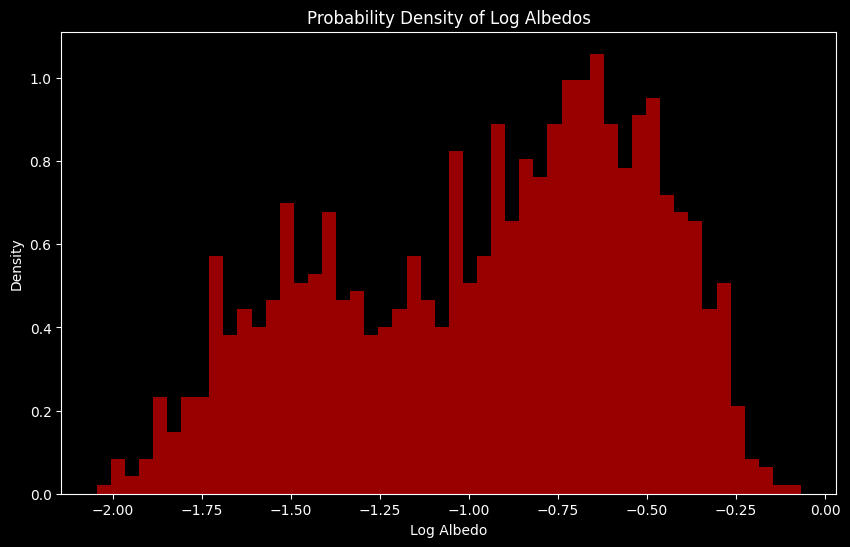

In [79]:
# Plot the probability density of log albedos
plt.figure(figsize=(10, 6))
log_albedo = np.log10(nea_wkn['albedo'])
plt.hist(log_albedo, bins=50, density=True, alpha=0.6, color='r')
plt.title('Probability Density of Log Albedos')
plt.xlabel('Log Albedo')
plt.ylabel('Density')
plt.show()


Fit distribution of albedos using multi gaussians:

In [80]:
albedo_data = np.log10(nea_wkn['albedo'])
F = mm.FitMoG(ngauss=10, nvars=1)
bounds=F.set_bounds(boundsm=((-5,5),),boundw=(0.1,0.9))
F.fit_data(albedo_data,advance=100,bounds=bounds,verbose=0)

Loading a FitMoG object.
Number of gaussians: 10
Number of variables: 1
Number of dimensions: 10
Number of samples: 0 (No data provided)
Iterations:
Iter 0:
	Vars: [1.2, 2, 1.6, 1.2, 1.5, 1.6, -0.84, -0.68, 1.2, -1.2, -1.2, -1.1, -1, -1, -0.99, -0.97, -0.96, -0.95, -0.94, -0.93, -3.2, -3.2, -3.2, -3.2, -3.2, -3.1, -3.1, -3.1, -3.1, -3.1]
	LogL/N: 0.6251654701490426
Iter 6:
	Vars: [-0.012, 0.95, 0.32, -0.29, 1.2, -1.7, -2.2, 0.98, 1.1, 1.1, -0.88, -0.48, -0.56, -0.77, -0.63, -0.69, -0.75, -1.6, -1.3, -1.3, -4.4, -4.3, -4, -3.6, -3.8, -5.8, -6.9, -4, -3.6, -3.5]
	LogL/N: 0.5043354203509213
FitMoG.fit_data executed in 1.6370728015899658 seconds


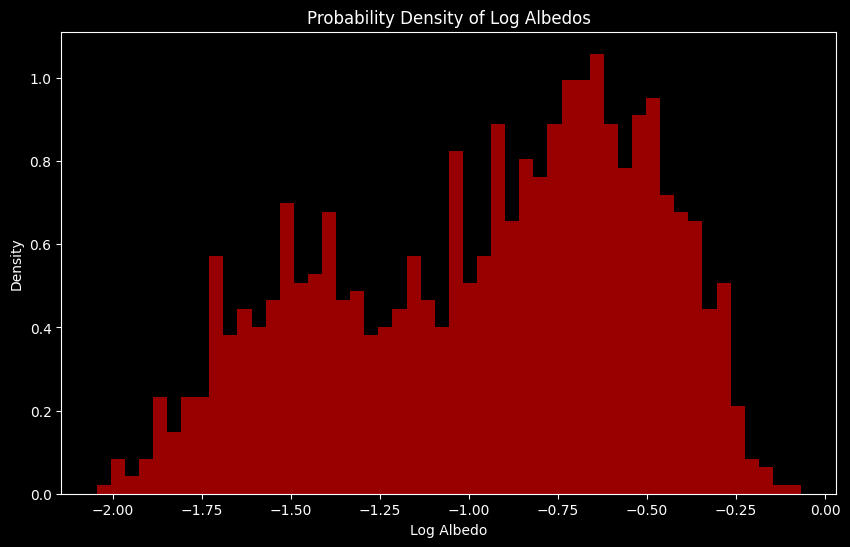

MixtureOfGaussians.rvs executed in 0.0707240104675293 seconds


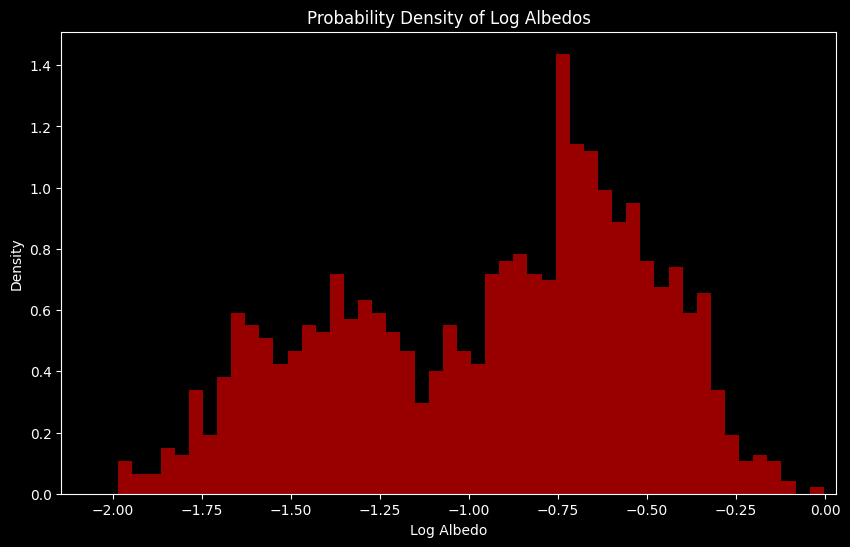

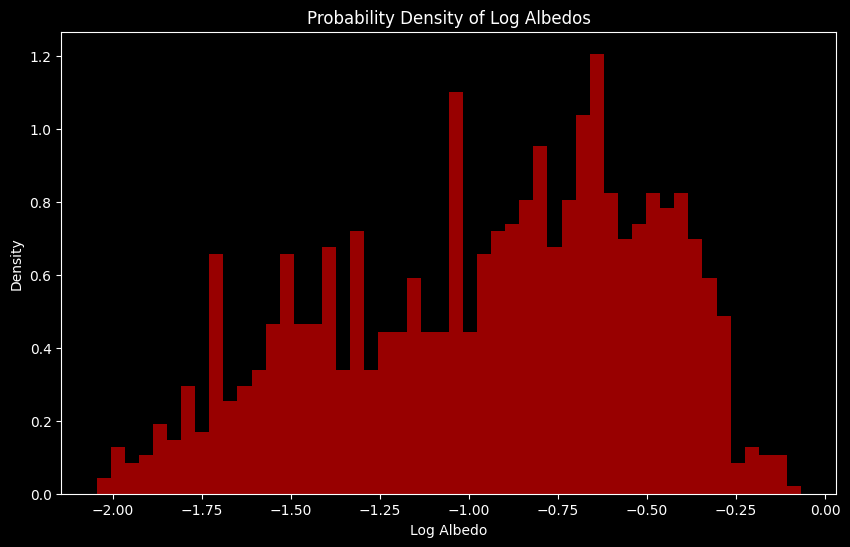

In [81]:
# Plot the probability density of log albedos
plt.figure(figsize=(10, 6))
log_albedo = np.log10(nea_wkn['albedo'])
plt.hist(log_albedo, bins=50, density=True, alpha=0.6, color='r')
plt.title('Probability Density of Log Albedos')
plt.xlabel('Log Albedo')
plt.ylabel('Density')
xmin,xmax = plt.xlim()
plt.show()

albedos_fake = F.mog.rvs(len(log_albedo))
# Plot the probability density of log albedos
plt.figure(figsize=(10, 6))
log_albedo = albedos_fake
plt.hist(log_albedo, bins=50, density=True, alpha=0.6, color='r')
plt.title('Probability Density of Log Albedos')
plt.xlabel('Log Albedo')
plt.ylabel('Density')
plt.xlim(xmin,xmax)
plt.show()

albedos_fake = np.random.choice(np.log10(nea_wkn['albedo'].values), len(log_albedo), replace=True)
# Plot the probability density of log albedos
plt.figure(figsize=(10, 6))
log_albedo = albedos_fake
plt.hist(log_albedo, bins=50, density=True, alpha=0.6, color='r')
plt.title('Probability Density of Log Albedos')
plt.xlabel('Log Albedo')
plt.ylabel('Density')
plt.xlim(xmin,xmax)
plt.show()


Now create a routine to estimate diameters of asteroids without albedo, by generating random albedos:

In [82]:
cond = (nea_db.diameter.isna()) & (nea_db.albedo.isna())
known_diameters = nea_db[~cond].diameter.values
Nunknown = cond.sum()
print(f"Number of NEAs with known diameter and known albedo: {len(known_diameters)}")
print(f"Number of NEAs with unknown diameter and unknown albedo: {Nunknown}")
print(f"Total known and unknown NEAs: {len(known_diameters) + Nunknown}")
print(f"Total number of NEAs: {len(nea_db)}")

Number of NEAs with known diameter and known albedo: 1247
Number of NEAs with unknown diameter and unknown albedo: 39664
Total known and unknown NEAs: 40911
Total number of NEAs: 40911


In [83]:
Ntrials = 1000
calculated_diameters = np.zeros((Ntrials, Nunknown))
for i in tqdm(range(Ntrials)):
    # generated_albedos = F.cmnd.rvs(num).flatten()
    generated_albedos = np.random.choice(np.log10(nea_wkn['albedo'].values), Nunknown, replace=True)

    # Take H from nea_db[cond]
    H_cond = nea_db.loc[cond, 'H'].values

    # Calculate diameters using the best-fit parameters
    calculated_diameters[i] = C_best * 10**(-a_best * H_cond) / np.sqrt(10**generated_albedos)

100%|██████████| 1000/1000 [00:01<00:00, 823.42it/s]


Test it:

In [84]:
a_min, a_max = nea_wkn['albedo'].min(), nea_wkn['albedo'].max()

i_test = 10
H_test = nea_db.loc[cond, 'H'].iloc[i_test]
d_max = C_best * 10**(-a_best * H_test) / np.sqrt(a_min)
d_min = C_best * 10**(-a_best * H_test) / np.sqrt(a_max)

print(f"Range of diameters for H = {H_test}: {d_min:.2f} (maximum albedo) - {d_max:.2f} (minimum albedo)")
print(f"Range of diameters for H = {H_test}: {calculated_diameters[:,i_test].min():.2f} - {calculated_diameters[:,i_test].max():.2f}")


Range of diameters for H = 17.27: 0.50 (maximum albedo) - 4.84 (minimum albedo)
Range of diameters for H = 17.27: 0.50 - 4.84


Construct sample with all diameters

In [85]:
i = 20
all_diameters = np.concatenate([known_diameters, calculated_diameters[i].flatten()])
Nall = len(all_diameters)
all_diameters

array([1.68400000e+01, 4.20000000e+00, 3.76750000e+01, ...,
       3.19272913e-02, 6.86000586e-02, 2.27496057e-01], shape=(40911,))

Histogram:

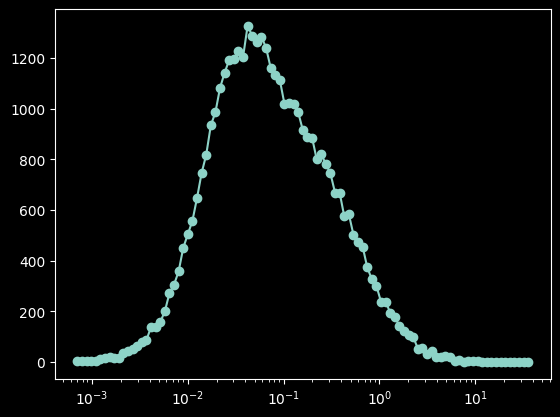

In [86]:
ds=np.logspace(np.log10(all_diameters.min()),np.log10(all_diameters.max()),100)
hs,xs = np.histogram(all_diameters,bins=ds)
xs = (xs[1:] + xs[:-1])/2
plt.semilogx(xs,hs,'o-')

Cummulative distribution:

Text(0.5, 1.0, 'N(>D)')

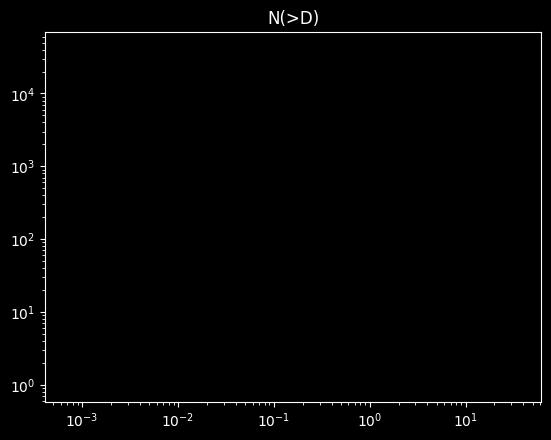

In [87]:
Qs = Nall - np.cumsum(hs)
plt.loglog(xs,Qs,"ko")
plt.title("N(>D)")

Fit distributtion:

p = -2.355534262578949, No = 1439.5022573515341


Text(0.5, 1.0, 'N(>D)')

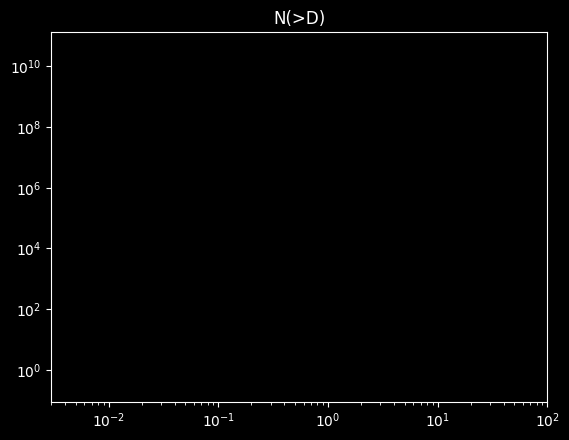

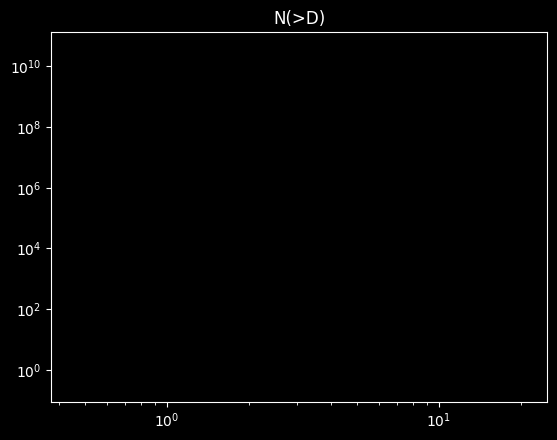

In [88]:
Dmin = 0.5
Dmax = 20
cond = (xs>Dmin)&(xs<Dmax)
ds_corte=xs[cond].reshape(-1,1)[:-1]
Qs_corte=Qs[cond].reshape(-1,1)[:-1]
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(np.log10(ds_corte),np.log10(Qs_corte))

p = model.coef_[0][0]
No = 10**model.intercept_[0]
print(f"p = {p}, No = {No}")

plt.figure()
plt.loglog(xs,Qs,"ko")
plt.loglog(xs,No*xs**p,"k-")
plt.xlim(3e-3,100)
plt.title("N(>D)")

plt.figure()
plt.loglog(xs,Qs,"ko")
plt.loglog(xs,No*xs**p,"k-")
plt.xlim(0.75*Dmin,1.25*Dmax)
plt.title("N(>D)")

Number of asteroid in a given range

In [89]:
D1 = 40e-3
D2 = 90e-3
N_not_found = No*(D1**p - D2**p)
N_found = all_diameters[(all_diameters>D1)&(all_diameters<D2)].shape[0]
print(f"Number of NEAs found: {N_found:.0f}")
print(f"Number of NEAs not found: {N_not_found:.0f} thounsands")
print(f"Percentage of NEAs found: {N_found/(N_found + N_not_found)*100:.2f}%")

Number of NEAs found: 9060
Number of NEAs not found: 2407242 thounsands
Percentage of NEAs found: 0.37%


In [90]:
D1 = 500e-3
D2 = 20000e-3
N_not_found = No*(D1**p - D2**p)
N_found = all_diameters[(all_diameters>D1)&(all_diameters<D2)].shape[0]
print(f"Number of NEAs found: {N_found:.0f}")
print(f"Number of NEAs not found: {N_not_found:.0f} thounsands")
print(f"Percentage of NEAs found: {N_found/(N_found + N_not_found)*100:.2f}%")

Number of NEAs found: 4097
Number of NEAs not found: 7366 thounsands
Percentage of NEAs found: 35.74%


Compute range of p:

In [91]:
Nunknown

np.int64(39664)

In [92]:
cond = (nea_db.diameter.isna()) & (nea_db.albedo.isna())
Nunknown = cond.sum()
H_cond = nea_db.loc[cond, 'H'].values

ps = []
Nos = []
Ntrials = 10000
for i in tqdm(range(Ntrials)):
    # Generate random albedos
    generated_albedos = np.random.choice(np.log10(nea_wkn['albedo'].values), Nunknown, replace=True)
    
    # Calculate diameters using the best-fit parameters
    calculated_diameters = C_best * 10**(-a_best * H_cond) / np.sqrt(10**generated_albedos)

    all_diameters = np.concatenate([known_diameters, calculated_diameters])
    Nall = len(all_diameters)

    # Cumulative distribution
    ds=np.logspace(np.log10(all_diameters.min()),np.log10(all_diameters.max()),100)
    hs,xs = np.histogram(all_diameters,bins=ds)
    xs = (xs[1:] + xs[:-1])/2
    Qs = Nall - np.cumsum(hs)

    # Fit model
    Dmin = 0.5
    Dmax = 20
    cond = (xs>Dmin)&(xs<Dmax)
    ds_corte=xs[cond].reshape(-1,1)[:-1]
    Qs_corte=Qs[cond].reshape(-1,1)[:-1]
    model=LinearRegression()
    model.fit(np.log10(ds_corte),np.log10(Qs_corte))

    # Coefficients
    ps += [model.coef_[0][0]]
    Nos += [10**model.intercept_[0]]

ps = np.array(ps)
Nos = np.array(Nos)

100%|██████████| 10000/10000 [00:22<00:00, 446.46it/s]


In [93]:
import numpy as np

# Calculate the quantiles
quantiles = np.percentile(ps, [5, 50, 95])

# Find the closest values in ps to the quantiles
closest_indices = [np.abs(ps - q).argmin() for q in quantiles]

# Extract the corresponding pairs of ps and Nos
quantile_pairs = [(ps[i], Nos[i]) for i in closest_indices]

# Print the results
pqs = dict()
Noqs = dict()
for q, (p, No) in zip([5, 50, 95], quantile_pairs):
    print(f"Quantile {q}%: p = {p}, No = {No}")
    pqs[q] = p
    Noqs[q] = No

Quantile 5%: p = -2.3822926291946827, No = 1305.635980741932
Quantile 50%: p = -2.3005092588656804, No = 1308.1339502556136
Quantile 95%: p = -2.2104968235711104, No = 1296.1068730543445


Text(0.5, 1.0, 'N(>D)')

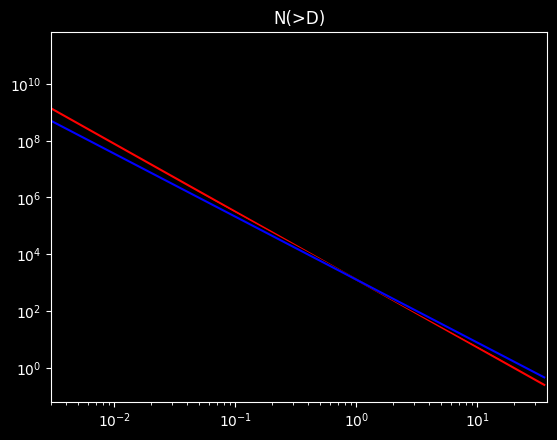

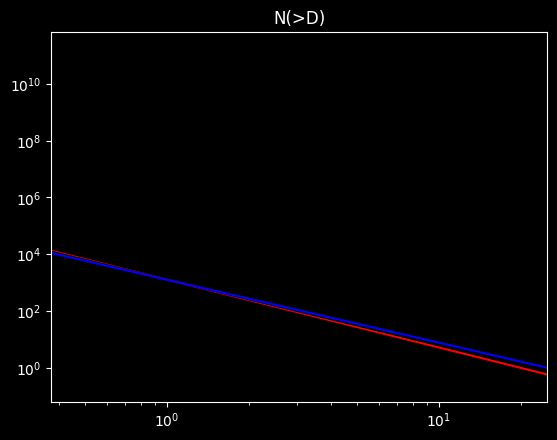

In [94]:
plt.figure()
plt.loglog(xs,Qs,"ko")
plt.loglog(xs,Noqs[5]*xs**pqs[5],"r-")
plt.loglog(xs,Noqs[50]*xs**pqs[50],"k-")
plt.loglog(xs,Noqs[95]*xs**pqs[95],"b-")
plt.xlim(3e-3,all_diameters.max())
plt.title("N(>D)")

plt.figure()
plt.loglog(xs,Qs,"ko")
plt.loglog(xs,Noqs[5]*xs**pqs[5],"r-")
plt.loglog(xs,Noqs[50]*xs**pqs[50],"k-")
plt.loglog(xs,Noqs[95]*xs**pqs[95],"b-")
plt.xlim(0.75*Dmin,1.25*Dmax)
plt.title("N(>D)")

Compare to Figure 9 in [Silber et al. (2018), Physics of meteor generated shock waves in the Earth’s atmosphere – A review](https://drive.google.com/file/d/1HxGHXCTPO2xJqD86WXFrvQUh6ZXnfm8E/view?usp=drive_link) and [Report of the Near-Earth Object Science Definition Team ](https://drive.google.com/file/d/1Hy67sUSsl-lPRETcQiNp7r4pIqX7N2Pp/view?usp=drive_link) (digitize Figure 2-B-2)

In [95]:
D1 = 40e-3
D2 = 90e-3
N_found = all_diameters[(all_diameters>D1)&(all_diameters<D2)].shape[0]
print(f"Number of NEAs found ({D1*1e3}<D<{D2*1e3} m): {N_found:.0f}")

Nmin = 1e100
Nmax = -1e100
for (q,p),(q,No) in zip(pqs.items(),Noqs.items()):
    print(f"Percentile {q}% (p = {p}, No = {No}):")
    N_not_found = No*(D1**p - D2**p)
    print(f"\tNumber of NEAs not found: {N_not_found:.0f}")
    print(f"\tPercentage of NEAs found: {N_found/(N_found + N_not_found)*100:.2f}%")
    Nmin = min(Nmin,N_not_found)
    Nmax = max(Nmax,N_not_found)

print(f"Range of NEAs not found: {Nmin:.0f} ({N_found/(Nmin + N_found)*100:.2f}%) - {Nmax:.0f} ({N_found/(Nmax + N_found)*100:.2f}%)")

Number of NEAs found (40.0<D<90.0 m): 9013
Percentile 5% (p = -2.3822926291946827, No = 1305.635980741932):
	Number of NEAs not found: 2388653
	Percentage of NEAs found: 0.38%
Percentile 50% (p = -2.3005092588656804, No = 1308.1339502556136):
	Number of NEAs not found: 1817943
	Percentage of NEAs found: 0.49%
Percentile 95% (p = -2.2104968235711104, No = 1296.1068730543445):
	Number of NEAs not found: 1329447
	Percentage of NEAs found: 0.67%
Range of NEAs not found: 1329447 (0.67%) - 2388653 (0.38%)


## Absolute magnitude

In [96]:
cond = (~nea_db.H.isna())
print(f"Number of NEAs with known H: {cond.sum()}")

Number of NEAs with known H: 40911


In [97]:
ds=np.linspace(nea_db[cond].H.max(),nea_db[cond].H.min(),100)
ds

array([34.37      , 34.11555556, 33.86111111, 33.60666667, 33.35222222,
       33.09777778, 32.84333333, 32.58888889, 32.33444444, 32.08      ,
       31.82555556, 31.57111111, 31.31666667, 31.06222222, 30.80777778,
       30.55333333, 30.29888889, 30.04444444, 29.79      , 29.53555556,
       29.28111111, 29.02666667, 28.77222222, 28.51777778, 28.26333333,
       28.00888889, 27.75444444, 27.5       , 27.24555556, 26.99111111,
       26.73666667, 26.48222222, 26.22777778, 25.97333333, 25.71888889,
       25.46444444, 25.21      , 24.95555556, 24.70111111, 24.44666667,
       24.19222222, 23.93777778, 23.68333333, 23.42888889, 23.17444444,
       22.92      , 22.66555556, 22.41111111, 22.15666667, 21.90222222,
       21.64777778, 21.39333333, 21.13888889, 20.88444444, 20.63      ,
       20.37555556, 20.12111111, 19.86666667, 19.61222222, 19.35777778,
       19.10333333, 18.84888889, 18.59444444, 18.34      , 18.08555556,
       17.83111111, 17.57666667, 17.32222222, 17.06777778, 16.81

Text(0.5, 1.0, 'N(<H)')

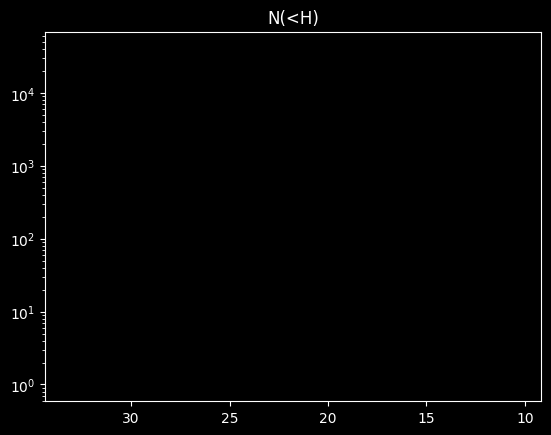

In [98]:
# Cumulative distribution
Nall = len(nea_db[cond])
Hmin = nea_db[cond].H.min()
Hmax = nea_db[cond].H.max()
ds = np.linspace(nea_db[cond].H.min(),nea_db[cond].H.max(),100)
hs,xs = np.histogram(nea_db[cond].H,bins=ds)
xs = (xs[1:] + xs[:-1])/2
Fs = np.cumsum(hs)
Qs = Nall - Fs

plt.semilogy(xs,Fs,"ko")
plt.xlim(Hmax,Hmin)
plt.title("N(<H)")


In [99]:
import os
import pandas as pd

In [100]:
completeness_file = neas.Util.get_data("completeness_silber2018.csv")
if os.path.exists(completeness_file):
    completeness = pd.read_csv(completeness_file)
    completeness = completeness.set_index('id')
completeness.head()

,H,F
id,,
0,30.264151,4.191514e+08
1,29.735849,2.855431e+08
2,29.245283,1.648975e+08
3,28.754717,1.006146e+08
4,28.226415,5.810970e+07


Text(0, 0.5, 'N(<H)')

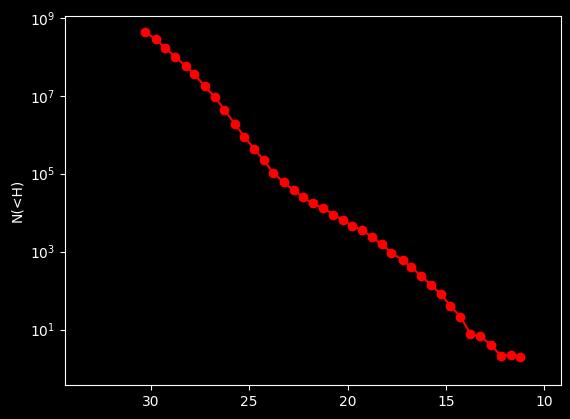

In [101]:
# Cumulative distribution
Hmin = nea_db[cond].H.min()
Hmax = nea_db[cond].H.max()
ds = np.linspace(nea_db[cond].H.min(),nea_db[cond].H.max(),100)
hs,xs = np.histogram(nea_db[cond].H,bins=ds)
xs = (xs[1:] + xs[:-1])/2
Fs = np.cumsum(hs)
Qs = Nall - Fs

plt.semilogy(xs,Fs,"ko")
plt.semilogy(completeness['H'],completeness['F'],'ro-')

plt.xlim(Hmax,Hmin)
plt.ylabel("N(<H)")

In [102]:
def linear_fit_Hmag(Hs, Fs, F_threshold=10, H_max=None, tail = []):

    # Thresholds
    Hmin = Hs[Fs > F_threshold][0]
    Hmax = H_max
    cond = (Hs>=Hmin)&(Hs<=Hmax)

    Hs = Hs[cond]
    Fs = Fs[cond]
        
    if len(tail)>0:
        Hs = np.concatenate((Hs,tail[0]))
        Fs = np.concatenate((Fs,tail[1]))
        
    # Linear fit
    Hs_corte=Hs.reshape(-1,1)[:-1]
    Fs_corte=Fs.reshape(-1,1)[:-1]    
    model=LinearRegression()
    model.fit(Hs_corte,np.log10(Fs_corte))

    # Coefficients
    a = model.coef_[0][0]
    b = model.intercept_[0]

    # Function
    FH_function = lambda H:10**(a*H+b)

    chi2 = chi2_cumsum(FH_function, Hs, Fs)

    return Hs, Fs, a, b, FH_function, chi2

def chi2_cumsum(FH_function, Hs, Fs, tail = []):

    # Add tail 
    if len(tail)>0:
        Hs = np.concatenate((Hs,tail[0]))
        Fs = np.concatenate((Fs,tail[1]))
    
    # Compute chi-square
    chi2 = ((np.log10(Fs) - np.log10(FH_function(Hs)))**2).sum()/np.log10(Fs.sum())

    return chi2


let's explore the slope:

In [103]:
F_threshold = 10
Hmax_min = Fs[Fs > F_threshold][1]
Hmaxs = np.linspace(Hmax_min,30,20)
bs = []
chi2s = []
for Hmax in Hmaxs:
    Heffs, Feffs, a, b, FH_function, chi2 = linear_fit_Hmag(xs, Fs, F_threshold=F_threshold, H_max=Hmax)
    bs += [b]
    chi2s += [chi2]
    print(f"Threshold: {Hmax:.2f}, a = {a:.2f}, b = {b:.2f}, chi2 = {chi2}")

Threshold: 16.00, a = 0.60, b = -7.28, chi2 = 0.0026552050959080037
Threshold: 16.74, a = 0.56, b = -6.61, chi2 = 0.005219763037045363
Threshold: 17.47, a = 0.52, b = -6.10, chi2 = 0.011698333581654268
Threshold: 18.21, a = 0.50, b = -5.80, chi2 = 0.017532815885804458
Threshold: 18.95, a = 0.47, b = -5.39, chi2 = 0.026371559333022095
Threshold: 19.68, a = 0.45, b = -5.03, chi2 = 0.040000550195026
Threshold: 20.42, a = 0.43, b = -4.68, chi2 = 0.0629453571725068
Threshold: 21.16, a = 0.41, b = -4.31, chi2 = 0.09918939663094875
Threshold: 21.89, a = 0.38, b = -3.94, chi2 = 0.15268979467638133
Threshold: 22.63, a = 0.36, b = -3.56, chi2 = 0.22538525726528527
Threshold: 23.37, a = 0.34, b = -3.19, chi2 = 0.31354884339380984
Threshold: 24.11, a = 0.32, b = -2.84, chi2 = 0.4111418794917296
Threshold: 24.84, a = 0.30, b = -2.52, chi2 = 0.5139418876872082
Threshold: 25.58, a = 0.29, b = -2.33, chi2 = 0.5870587368381363
Threshold: 26.32, a = 0.27, b = -2.05, chi2 = 0.7068388946565551
Threshold: 

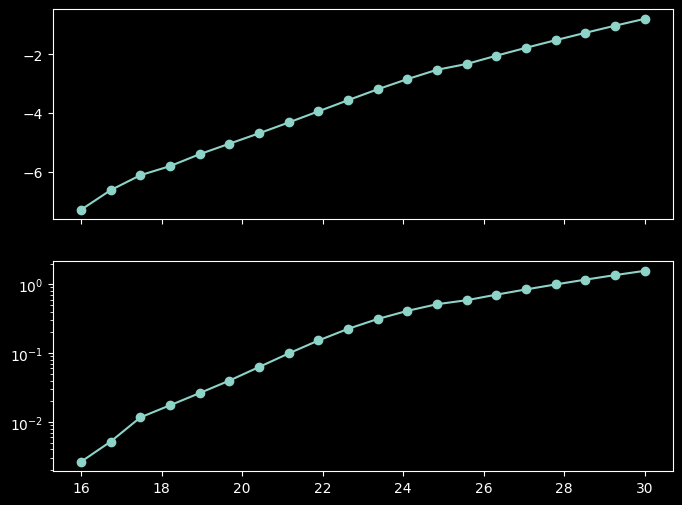

In [104]:
fig,axs = plt.subplots(2,1,figsize=(8,6),sharex=True)
ax = axs[0]
ax.plot(Hmaxs,bs,'o-')

ax = axs[1]
ax.semilogy(Hmaxs,chi2s,'o-')
#ax.plot(Hmaxs,chi2s,'o-')

In [105]:
F_threshold = 10

cond = Fs > F_threshold
Hmin = xs[cond][0]
Hmax_ini = xs[cond][1]
Hmax_end = xs[cond][-1]

Hmax = Hmax_ini
print(f"Hmax: {Hmax:.2f}")
Heffs,Feffs,a,b,FH_function,chi2 = linear_fit_Hmag(xs, Fs, F_threshold=F_threshold, H_max=Hmax, tail=[])
print(f"\tChi-2 no tail: {chi2}")

cond = completeness.H > 25
tail = [completeness[cond]['H'],completeness[cond]['F']]
chi2 = chi2_cumsum(FH_function,Heffs,Feffs,tail=tail)
print(f"\tChi-2 tail: {chi2}")

Hmax: 14.14
	Chi-2 no tail: 0.010786443199157985
	Chi-2 tail: 49.91979462574835


In [106]:
F_threshold = 10
H_bolide_completeness = +25

cond = Fs > F_threshold
Hmin = xs[cond][0]
Hmax_ini = xs[cond][1]
Hmax_end = xs[cond][-1]

Hmax_min = Hmax_ini
chi2_min = 1e100
for Hmax in np.linspace(Hmax_ini,Hmax_end,100):
    print(f"Hmax: {Hmax:.2f}")
    Heffs,Feffs,a,b,FH_function,chi2 = linear_fit_Hmag(xs, Fs, F_threshold=F_threshold, H_max=Hmax, tail=[])
    print(f"\tChi-2 no tail: {chi2}")

    cond = completeness.H > H_bolide_completeness
    tail = [completeness[cond]['H'],completeness[cond]['F']]
    chi2 = chi2_cumsum(FH_function,Heffs,Feffs,tail=tail)
    print(f"\tChi-2 tail: {chi2}")
    if chi2 < chi2_min:
        chi2_min = chi2
        Hmax_min = Hmax

Hmax: 14.14
	Chi-2 no tail: 0.010786443199157985
	Chi-2 tail: 49.91979462574835
Hmax: 14.34
	Chi-2 no tail: 0.010786443199157985
	Chi-2 tail: 49.91979462574835
Hmax: 14.55
	Chi-2 no tail: 0.001524810870815342
	Chi-2 tail: 0.269782984333879
Hmax: 14.75
	Chi-2 no tail: 0.00023307008729766163
	Chi-2 tail: 4.151473976919475
Hmax: 14.95
	Chi-2 no tail: 0.0009025388434763173
	Chi-2 tail: 3.8875329125800477
Hmax: 15.16
	Chi-2 no tail: 0.0009025388434763173
	Chi-2 tail: 3.8875329125800477
Hmax: 15.36
	Chi-2 no tail: 0.0004545455084937002
	Chi-2 tail: 5.895979884574657
Hmax: 15.56
	Chi-2 no tail: 0.0004289955865917295
	Chi-2 tail: 5.726743222465905
Hmax: 15.77
	Chi-2 no tail: 0.001310133438212169
	Chi-2 tail: 5.877850223855037
Hmax: 15.97
	Chi-2 no tail: 0.0026552050959080037
	Chi-2 tail: 4.782758754900977
Hmax: 16.17
	Chi-2 no tail: 0.0026552050959080037
	Chi-2 tail: 4.782758754900977
Hmax: 16.38
	Chi-2 no tail: 0.00343247775656206
	Chi-2 tail: 3.6742701461431317
Hmax: 16.58
	Chi-2 no tail: 0.

In [107]:
float(Hmax_min), chi2_min

(19.623787878787876, np.float64(0.05240142748408948))

In [108]:
from scipy.optimize import minimize
F_threshold = 10
H_bolide_completeness = +28

cond = Fs > F_threshold
Hmin = xs[cond][0]
Hmax_ini = xs[cond][1]
Hmax_end = xs[cond][-1]

cond = completeness.H > H_bolide_completeness
tail = [completeness[cond]['H'],completeness[cond]['F']]
def completeness_chi2(Hmax):
    Heffs,Feffs,a,b,FH_function,chi2 = linear_fit_Hmag(xs, Fs, F_threshold=F_threshold, H_max=Hmax)
    chi2 = chi2_cumsum(FH_function,Heffs,Feffs,tail=tail)
    return chi2

solution = minimize(completeness_chi2, Hmax_min, method='Nelder-Mead')
solution

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.018312934363959837
             x: [ 1.938e+01]
           nit: 15
          nfev: 41
 final_simplex: (array([[ 1.938e+01],
                       [ 1.938e+01]]), array([ 1.831e-02,  1.831e-02]))

Text(0.5, 1.0, 'N(>D)')

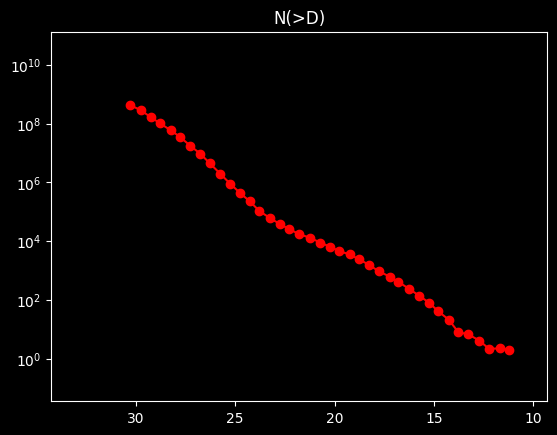

In [109]:
Heffs,Feffs,a,b,FH_function,chi2 = linear_fit_Hmag(xs, Fs, F_threshold=F_threshold, H_max=solution.x[0])

plt.figure()
plt.semilogy(xs,Fs,"ko")
plt.semilogy(xs,FH_function(xs),"k-")
plt.semilogy(completeness['H'],completeness['F'],'ro-')
plt.xlim(xs.max(),xs.min())
plt.title("N(>D)")

### Completeness analysis: synthesis

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.optimize import minimize
from datetime import datetime

plt.style.use('dark_background')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [111]:
neo_db_file = f"{pm.data_dir}/{pm.NEO_DB_JSON_FILE}"
neo_db_time = os.path.getmtime(neo_db_file)
neo_db_date = datetime.fromtimestamp(neo_db_time)

neo_db = pm.read_neo_db(f"{pm.data_dir}/",type='df')
nea_db = neo_db[neo_db['kind'].isin(['an', 'au'])]
nea_db = nea_db.dropna(subset=['H'])
print(f"Number of NEAs (with known H): {len(nea_db)}")

completeness_file = f"../{pm.data_dir}/completeness_silber2018.csv"
if os.path.exists(completeness_file):
    completeness = pd.read_csv(completeness_file)
    completeness = completeness.set_index('id')
else:
    print(f"File {completeness_file} not found")

cond = (~nea_db.H.isna())
print(f"Number of NEAs with known H: {cond.sum()}")

Loaded neo_db with 41122 objects from data//neo_db.csv.gz
Number of NEAs (with known H): 40911
File ../data/completeness_silber2018.csv not found
Number of NEAs with known H: 40911


Text(0, 0.5, 'N(<H)')

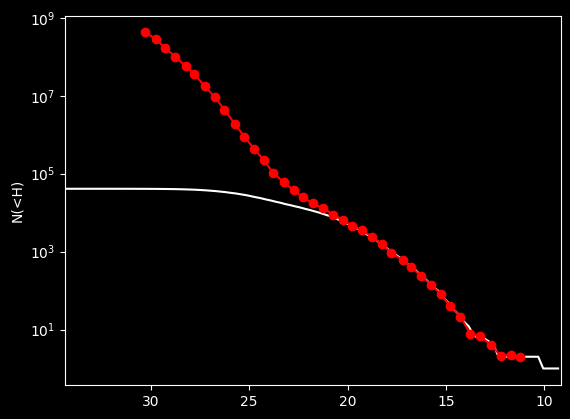

In [113]:
# Cumulative distribution
cond = (~nea_db.H.isna())
Hmin = nea_db[cond].H.min()
Hmax = nea_db[cond].H.max()
fs,Hs = np.histogram(nea_db[cond].H,bins=100)
Hs = (Hs[1:] + Hs[:-1])/2
Fs = np.cumsum(fs)
len(Hs,)

# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
# Verification
# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
plt.semilogy(Hs,Fs,"w-")
plt.semilogy(completeness['H'],completeness['F'],'ro-')
plt.xlim(Hmax,Hmin)
plt.ylabel("N(<H)")

In [115]:
F_threshold = 10
Hmin = Hs[Fs > F_threshold][0]
H_bolide_completeness = +28
H_guess = +20

cond = completeness.H > H_bolide_completeness
tail = [completeness[cond]['H'],completeness[cond]['F']]
def completeness_chi2(Hmax):
    Heffs,Feffs,a,b,FH_function,chi2 = pm.linear_fit_Hmag(Hs, Fs, F_threshold=F_threshold, H_max=Hmax)
    chi2 = pm.chi2_cumsum(FH_function,Heffs,Feffs,tail=tail)
    return chi2

solution = minimize(completeness_chi2, H_guess, method='Nelder-Mead')
solution

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.015636245801647578
             x: [ 1.925e+01]
           nit: 16
          nfev: 43
 final_simplex: (array([[ 1.925e+01],
                       [ 1.925e+01]]), array([ 1.564e-02,  1.564e-02]))

(np.float64(0.45825555268416973), np.float64(-5.138457374762216))

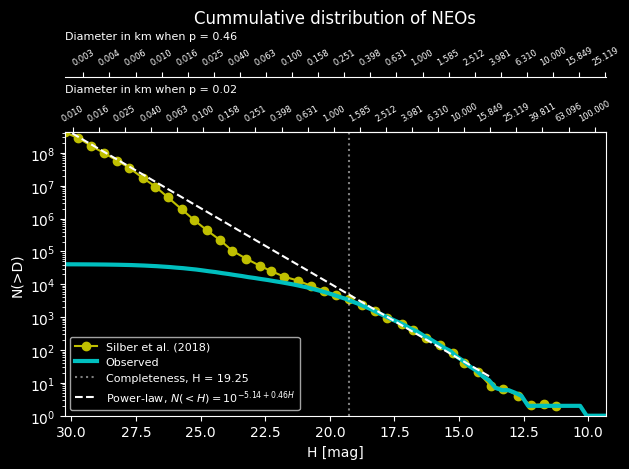

In [116]:
# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
# Verification
# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
H_completeness = solution.x[0]
Heffs,Feffs,a,b,FH_function,chi2 = pm.linear_fit_Hmag(Hs, Fs, F_threshold=F_threshold, H_max=H_completeness)

# Figure
fig,axs = plt.subplots(1,1)
ax = axs

# Silber et al. (2018)
ax.semilogy(completeness['H'],completeness['F'],'yo-',label='Silber et al. (2018)')
# Observed NEAs
ax.semilogy(Hs,Fs,"c-",lw=3,label='Observed')
# Completeness
ax.axvline(H_completeness, color='w', linestyle=':', alpha=0.5, label=f"Completeness, H = {H_completeness:.2f}")
# Power law fit
Htests = np.linspace(Hmin,Hs.max(),100)
ax.semilogy(Htests,FH_function(Htests),"w--",label=rf"Power-law, $N(<H) = 10^{{{b:.2f}+{a:.2f}H}}$")

# Decoration
ax.set_xlim(completeness['H'].max(),Hs.min())
ax.set_ylim(1,completeness['F'].max())

# Secondary axis for diameter
p1 = 0.02
secax = ax.secondary_xaxis('top', functions=(lambda H: C_best * 10**(-a_best * H) / np.sqrt(p1), 
                                             lambda D: -np.log10(D / C_best) / a_best + 2 * np.log10(p1) / a_best))
secax.set_xlabel(f"Diameter in km when p = {p1}", fontsize=8, loc='left')

# Set ticks for the secondary axis
diameter_intervals = []
for i in range(-3, 3):
    diameter_intervals.extend(np.logspace(i, i+1, 5, endpoint=False))
secax.set_xticks(diameter_intervals)
secax.set_xticklabels([f"{d:.3f}" for d in diameter_intervals])
for label in secax.get_xticklabels():
    label.set_rotation(30)
# Set tick label size
secax.tick_params(axis='x', labelsize=6)

# Third axis for a different albedo value
p2 = 0.46
third_ax = ax.secondary_xaxis('top', functions=(lambda H: C_best * 10**(-a_best * H) / np.sqrt(p2), 
                                                lambda D: -np.log10(D / C_best) / a_best + 2 * np.log10(p2) / a_best))

third_ax.set_xlabel(f"Diameter in km when p = {p2}", fontsize=8, loc='left')
third_ax.spines['top'].set_position(('outward', 40))

# Set ticks for the third axis
third_ax.set_xticks(diameter_intervals)
third_ax.set_xticklabels([f"{d:.3f}" for d in diameter_intervals])
for label in third_ax.get_xticklabels():
    label.set_rotation(30)
# Set tick label size
third_ax.tick_params(axis='x', labelsize=6)

ax.set_ylabel("N(>D)")
ax.set_xlabel("H [mag]")

ax.legend(fontsize=8, loc='lower left')
ax.set_title("Cummulative distribution of NEOs")

fig.tight_layout()
a,b

## Convert H magnitude to diameter

Design a routine to convert from H magnitude to diameter

In [118]:
C_std = 1329.22 # km
a_std = 0.2

def Hmag2diameter(H, albedo=1.0, C=C_std, a=a_std):
    """Convert from absolute magnitude H to diameter in km

    Args:
        H: float or nd.array (size=n_h, units: mag)
            Absolute magnitude.
        
        albedo: float or iterable (tuple, list, nd.array) (size=n_a, units: admin)
            Geometric albedo.

    Optional arguments: 
        C: float [default = C_std] (units: km)
            Size parameter in the law: D = C 10^(-aH)/sqrt(p)

        a: float [default = a_str] (units: 1/mag)
            Exponent parameter in the law: D = C 10^(-aH)/sqrt(p)

    Return:
        diameters: float or nd.array (n_h x n_a, units: km)
            Diameter(s)

    Examples:
        >>> Hmag2diameter(30,albedo=[0.1,1])
        >>> Hmag2diameter(np.array([10,15,20]),albedo=[0.1,1])
    """
    if isinstance(albedo, (tuple, list, np.ndarray)):
        albedos = np.array(albedo)
        diameters = np.array([C * 10**(-a * H) / np.sqrt(albedo) for albedo in albedos])
    else:
        diameters = float(C * 10**(-a * H) / np.sqrt(albedo))
    return diameters

def diameter2Hmag(diameter, albedo=1.0, C=C_std, a=a_std):
    """Convert from diameter in km to absolute magnitude H 

    Args:
        diameters: float or nd.array (size=n_h, units: km)
            Diameter(s)
        
        albedo: float or iterable (tuple, list, nd.array) (size=n_a, units: admin)
            Geometric albedo.

    Optional arguments: 
        C: float [default = C_std] (units: km)
            Size parameter in the law: D = C 10^(-aH)/sqrt(p)

        a: float [default = a_str] (units: 1/mag)
            Exponent parameter in the law: D = C 10^(-aH)/sqrt(p)

    Return:
        H: float or nd.array (n_h x n_a, units: mag)
            Absolute magnitude.

    Examples:
        >>> diameter2Hmag(0.5,albedo=[0.1,1])
    """
    if isinstance(diameter, (tuple, list, np.ndarray)):
        diameters = np.array(diameter)
        Hmags = np.array([-np.log10(diameters*np.sqrt(albedo)/C)/a for diameter in diameters])
    else:
        Hmags = -np.log10(diameter*np.sqrt(albedo)/C)/a
    return Hmags

Hmag2diameter(30,albedo=[0.1,1]), diameter2Hmag(0.5,albedo=[0.1,1]), Hmag2diameter(np.array([10,15,20]),albedo=[0.1,1])

(array([0.00420336, 0.00132922]),
 array([19.62313431, 17.12313431]),
 array([[42.03362711,  4.20336271,  0.42033627],
        [13.2922    ,  1.32922   ,  0.132922  ]]))

In [119]:
pm.Hmag2diameter(30,albedo=[0.1,1]), pm.diameter2Hmag(0.5,albedo=[0.1,1]), pm.Hmag2diameter(np.array([10,15,20]),albedo=[0.1,1])

(array([0.00420336, 0.00132922]),
 array([19.62313431, 17.12313431]),
 array([[42.03362711,  4.20336271,  0.42033627],
        [13.2922    ,  1.32922   ,  0.132922  ]]))

### Albedo statistics

In [120]:
# NEAs well-known
nea_wkn = nea_db.dropna(subset=['albedo','diameter'])

# Drop neas with extent instead of diameter
nea_wkn = nea_wkn[nea_wkn['extent'].isna()]
print(f"Number of well-known NEAs: {len(nea_wkn)}")

Number of well-known NEAs: 1194


Fitting H-d relationship function parameters:

In [121]:
C_std = 1329.22
a_std = 0.2

# Define the model function
def diameter_model(H, C, a, p):
    return C * 10**(-a * H) / p**0.5

# Extract the necessary data
H = nea_wkn['H'].values
p = nea_wkn['albedo'].values
diameter = nea_wkn['diameter'].values

# Initial guess for the parameters
initial_guess = [1329.22, 0.2]

# Perform the curve fitting
params, covariance = curve_fit(lambda H, C, a: diameter_model(H, C, a, p), H, diameter, p0=initial_guess)

# Extract the best-fit parameters
C_best, a_best = params

print(f"Standard parameters: C = {C_std}, a = {a_std}")
print(f"Best-fit parameters: C = {C_best}, a = {a_best}")

Standard parameters: C = 1329.22, a = 0.2
Best-fit parameters: C = 1209.044729988792, a = 0.19806816990606088


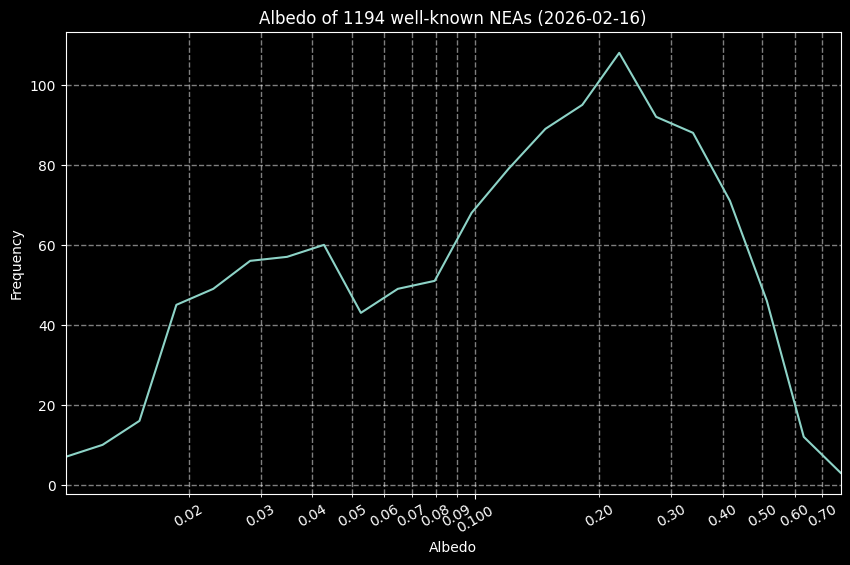

In [122]:
from matplotlib.ticker import ScalarFormatter

# Plot the probability density of log albedos
fig,axs = plt.subplots(1,1,figsize=(10, 6))
ax = axs

n_albedo = len(nea_wkn)
lps = np.logspace(np.log10(nea_wkn['albedo'].min()),
                  np.log10(nea_wkn['albedo'].max()),
                  int(n_albedo/50))
fs,ps = np.histogram(nea_wkn['albedo'],bins=lps)
ps = (ps[1:] + ps[:-1])/2
hs = fs/np.sum(fs)

ax.semilogx(ps, fs, '-')

# Decoration
ax.margins(x=0)
ax.set_title(f"Albedo of {n_albedo} well-known NEAs ({neo_db_date.strftime('%Y-%m-%d')})")
ax.set_xlabel("Albedo")
ax.set_ylabel(f"Frequency")

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(ScalarFormatter())
ax.tick_params(axis='x', which='major', labelrotation=30)
ax.tick_params(axis='x', which='minor', labelrotation=30)
ax.grid(which='both', linestyle='--', linewidth=1, alpha=0.5)

In [123]:
albedos = nea_wkn['albedo'].values
np.quantile(albedos, [0.05, 0.5, 0.95])

array([0.019, 0.137, 0.461])